In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r".\Datasets\titanic-dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.Age.mean()

29.69911764705882

In [8]:
df.Age.fillna(df.Age.mean(), inplace = True)

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.Embarked.mode()

0    S
Name: Embarked, dtype: object

In [11]:
for i in ['Embarked']: df.Embarked.replace([np.NaN], df.Embarked.mode(), inplace = True)

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [13]:
df.Cabin.mode()

0        B96 B98
1    C23 C25 C27
2             G6
Name: Cabin, dtype: object

In [14]:
df.describe(include = 'O')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,891
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,646


In [15]:
df.describe(include = 'O')['Cabin'][2]

'B96 B98'

In [16]:
for i in ['Cabin']: df.Cabin.replace([np.NaN], df.describe(include = 'O')[i][2], inplace = True)

In [17]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [18]:
df1 = df.drop(['Name', 'PassengerId', 'Ticket', 'Cabin'], axis = 1)
df1

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S
887,1,1,female,19.000000,0,0,30.0000,S
888,0,3,female,29.699118,1,2,23.4500,S
889,1,1,male,26.000000,0,0,30.0000,C


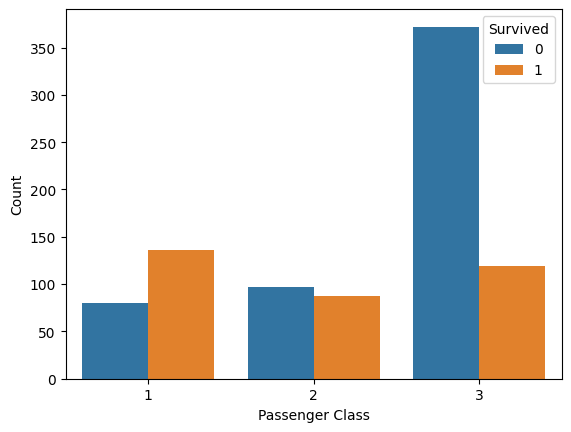

In [19]:
sns.countplot(x = df.Pclass, hue = df.Survived)
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

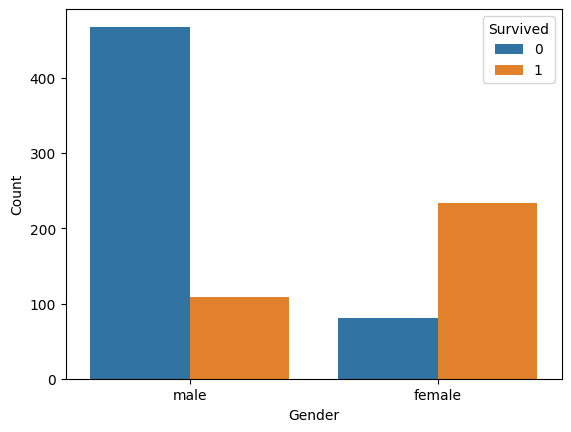

In [20]:
sns.countplot(x = df.Sex, hue = df.Survived)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

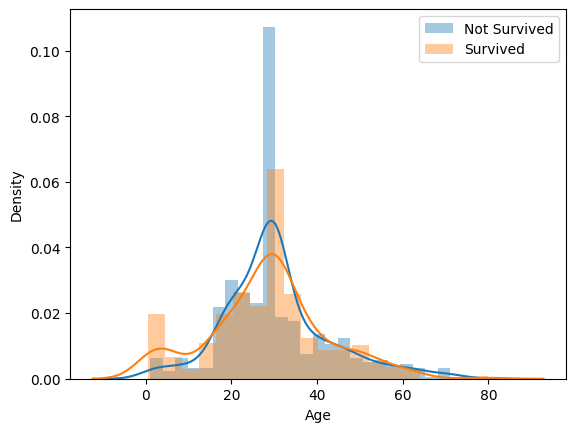

In [21]:
sns.distplot(df.Age[df.Survived == 0], label = 'Not Survived')
sns.distplot(df.Age[df.Survived == 1], label = 'Survived')
plt.legend()
plt.show()

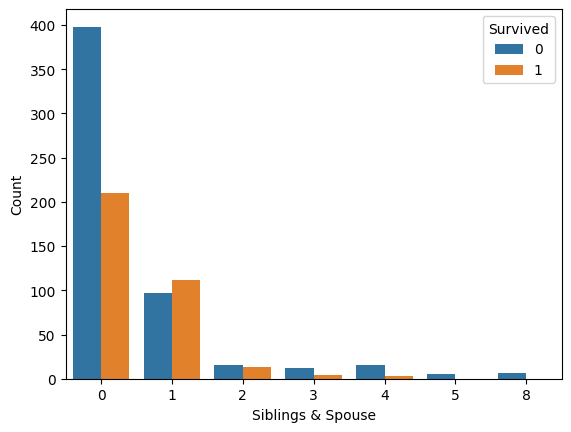

In [22]:
sns.countplot(x = df.SibSp, hue = df.Survived)
plt.xlabel('Siblings & Spouse')
plt.ylabel('Count')
plt.show()

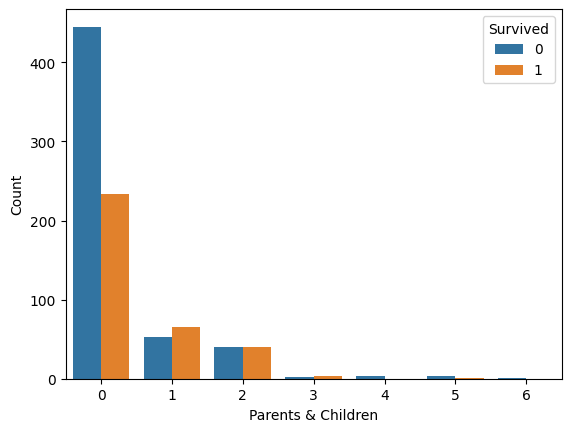

In [23]:
sns.countplot(x = df.Parch, hue = df.Survived)
plt.xlabel('Parents & Children')
plt.ylabel('Count')
plt.show()

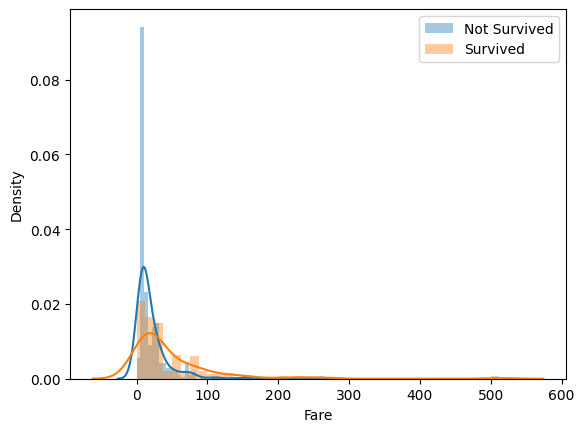

In [24]:
sns.distplot(df.Fare[df.Survived == 0], label = 'Not Survived')
sns.distplot(df.Fare[df.Survived == 1], label = 'Survived')
plt.legend()
plt.show()

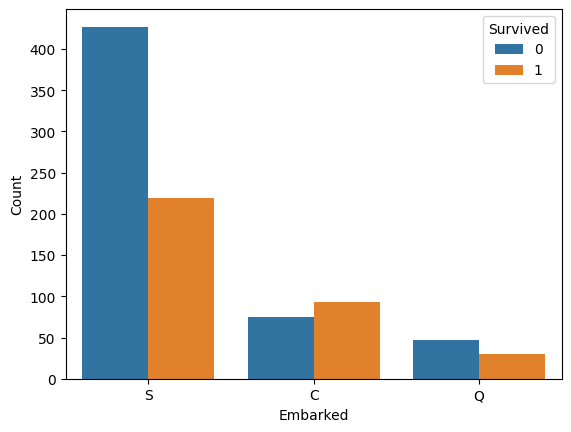

In [25]:
sns.countplot(x = df.Embarked, hue = df.Survived)
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.show()

In [26]:
le1 = LabelEncoder()
le1

LabelEncoder()

In [27]:
df1.Sex = le1.fit_transform(df1.Sex)
df1

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.000000,1,0,7.2500,S
1,1,1,0,38.000000,1,0,71.2833,C
2,1,3,0,26.000000,0,0,7.9250,S
3,1,1,0,35.000000,1,0,53.1000,S
4,0,3,1,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,S
887,1,1,0,19.000000,0,0,30.0000,S
888,0,3,0,29.699118,1,2,23.4500,S
889,1,1,1,26.000000,0,0,30.0000,C


In [28]:
le1.inverse_transform([1,0])

array(['male', 'female'], dtype=object)

In [29]:
le2 = LabelEncoder()
le2

LabelEncoder()

In [30]:
df1.Embarked = le2.fit_transform(df1.Embarked)
df1

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.000000,1,0,7.2500,2
1,1,1,0,38.000000,1,0,71.2833,0
2,1,3,0,26.000000,0,0,7.9250,2
3,1,1,0,35.000000,1,0,53.1000,2
4,0,3,1,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,2
887,1,1,0,19.000000,0,0,30.0000,2
888,0,3,0,29.699118,1,2,23.4500,2
889,1,1,1,26.000000,0,0,30.0000,0


In [31]:
le2.inverse_transform([2,1,0])

array(['S', 'Q', 'C'], dtype=object)

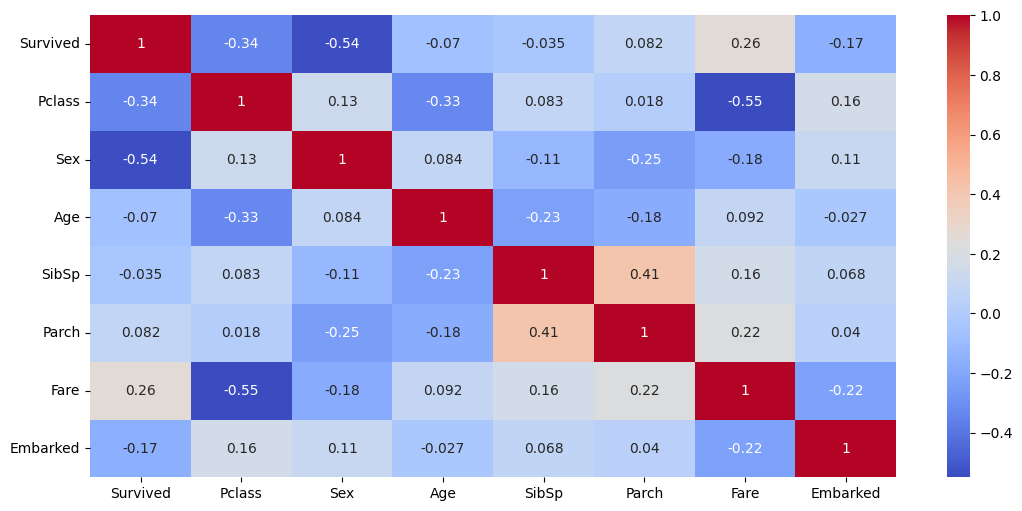

In [32]:
plt.figure(figsize = (13,6))
sns.heatmap(df1.corr(), annot = True, cmap = 'coolwarm')
plt.yticks(rotation = 0)
plt.show()

In [33]:
ip = df1.drop(['Survived'], axis = 1)
ip

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.000000,1,0,7.2500,2
1,1,0,38.000000,1,0,71.2833,0
2,3,0,26.000000,0,0,7.9250,2
3,1,0,35.000000,1,0,53.1000,2
4,3,1,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000,2
887,1,0,19.000000,0,0,30.0000,2
888,3,0,29.699118,1,2,23.4500,2
889,1,1,26.000000,0,0,30.0000,0


In [34]:
op = df1['Survived']
op

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [35]:
x_train, x_test, y_train, y_test = train_test_split(ip, op, train_size = 0.7)
df.shape, x_train.shape, x_test.shape

((891, 12), (623, 7), (268, 7))

In [36]:
sc = StandardScaler()
sc

StandardScaler()

In [37]:
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [38]:
log = LogisticRegression()
log.fit(x_train, y_train)

LogisticRegression()

In [39]:
ycap = log.predict(x_test)
ycap

array([0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0], dtype=int64)

In [40]:
pdf = pd.DataFrame({'y':list(y_test),
                    'Prediction':ycap})
pdf

,y,Prediction
0,0,0
1,0,0
2,0,0
3,1,1
4,0,0
...,...,...
263,0,0
264,0,0
265,0,0
266,1,1


In [41]:
cm = confusion_matrix(y_test, ycap)
pd.DataFrame(cm)

,0,1
0,138,27
1,29,74


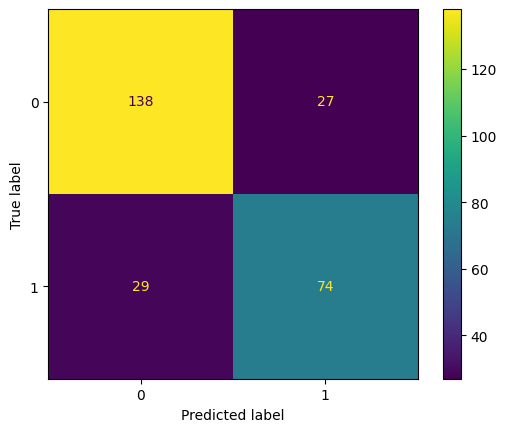

In [42]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [43]:
acs = accuracy_score(y_test, ycap)
rcs = recall_score(y_test, ycap)
prs = precision_score(y_test, ycap)
f1s = f1_score(y_test, ycap)
print("Accuracy Score:", acs)
print("Recall Score:", rcs)
print("Precision Score:", prs)
print("F1 Score:", f1s)

Accuracy Score: 0.7910447761194029
Recall Score: 0.7184466019417476
Precision Score: 0.7326732673267327
F1 Score: 0.7254901960784315
